<a href="https://colab.research.google.com/github/caio-fiap/CP05-SERS/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [2]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [3]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [4]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


Execute a célula abaixo. Caso a conexão com a API falhe, pule para a etapa dos imports

In [5]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [6]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [7]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


##Imports necessários para as tarefas:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [9]:
# 1. Análise inicial do dataset

df_class = pd.read_csv("aneel_classificacao_orange.csv")

print(f"{'-'*5} Informações do dataset {'-'*5}")
df_class.info()

print(f"\n{'-'*5} Primeiras linhas {'-'*5}")
display(df_class.head())

print(f"\n{'-'*5} Valores ausentes {'-'*5}")
print(df_class.isnull().sum())

print(f"\n{'-'*5} Contagens por classe {'-'*5}")
print(df_class["fonte"].value_counts())

print(f"\n{'-'*5} Resumo estatístico {'-'*5}")
display(df_class.describe())

----- Informações do dataset -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

----- Primeiras linhas -----


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar



----- Valores ausentes -----
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

----- Contagens por classe -----
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

----- Resumo estatístico -----


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


In [11]:
# 2.
# Definição de X, Y e divisão treino/teste
X_class = df_class[["potencia_kw", "latitude", "longitude"]]
y_class = df_class["fonte"]

# dividir 80/20 teste e treino
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [32]:
# 3. Treinamento e avaliação dos três classificadores

# KNN

modelo_knn = Pipeline([("scaler", StandardScaler()),("knn", KNeighborsClassifier())])

modelo_knn.fit(X_train_c, y_train_c)
y_pred_knn = modelo_knn.predict(X_test_c)

acc_knn = accuracy_score(y_test_c, y_pred_knn)
prec_knn = precision_score(y_test_c, y_pred_knn, average="macro")
rec_knn = recall_score(y_test_c, y_pred_knn, average="macro")
f1_knn = f1_score(y_test_c, y_pred_knn, average="macro")

print(f"{'-'*5} Métricas KNN {'-'*5}")
print(f"Acurácia:           {acc_knn:.4f}")
print(f"Precisão:           {prec_knn:.4f}")
print(f"Recall:             {rec_knn:.4f}")
print(f"F1:                 {f1_knn:.4f}")

# Regressão Logística

modelo_reg = Pipeline([("scaler", StandardScaler()),("logistic", LogisticRegression(max_iter=1000, random_state=42))])

modelo_reg.fit(X_train_c, y_train_c)
y_pred_reg = modelo_reg.predict(X_test_c)

acc_reg = accuracy_score(y_test_c, y_pred_reg)
prec_reg = precision_score(y_test_c, y_pred_reg, average="macro")
rec_reg = recall_score(y_test_c, y_pred_reg, average="macro")
f1_reg = f1_score(y_test_c, y_pred_reg, average="macro")

print(f"\n{'-'*5} Métricas Regressão Logística {'-'*5}")
print(f"Acurácia:           {acc_reg:.4f}")
print(f"Precisão:           {prec_reg:.4f}")
print(f"Recall:             {rec_reg:.4f}")
print(f"F1:                 {f1_reg:.4f}")

# Random Forest

modelo_rfor = RandomForestClassifier(n_estimators=100,random_state=42)

modelo_rfor.fit(X_train_c, y_train_c)
y_pred_rfor = modelo_rfor.predict(X_test_c)

acc_rfor = accuracy_score(y_test_c, y_pred_rfor)
prec_rfor = precision_score(y_test_c, y_pred_rfor, average="macro")
rec_rfor = recall_score(y_test_c, y_pred_rfor, average="macro")
f1_rfor = f1_score(y_test_c, y_pred_rfor, average="macro")

print(f"\n{'-'*5} Métricas Random Forest {'-'*5}")
print(f"Acurácia:           {acc_rfor:.4f}")
print(f"Precisão:           {prec_rfor:.4f}")
print(f"Recall:             {rec_rfor:.4f}")
print(f"F1:                 {f1_rfor:.4f}")

----- Métricas KNN -----
Acurácia:           0.9665
Precisão:           0.9677
Recall:             0.9649
F1:                 0.9662

----- Métricas Regressão Logística -----
Acurácia:           0.8235
Precisão:           0.8275
Recall:             0.8200
F1:                 0.8182

----- Métricas Random Forest -----
Acurácia:           0.9755
Precisão:           0.9769
Recall:             0.9741
F1:                 0.9753


In [18]:
# Comparação dos três classificadores

resultados_classificacao = pd.DataFrame({
    "Modelo": ["KNN","Regressão Logística","Random Forest"],
    "Acurácia": [acc_knn,acc_reg,acc_rfor],
    "Precisão": [prec_knn,prec_reg,prec_rfor],
    "Recall": [rec_knn,rec_reg,rec_rfor],
    "F1": [f1_knn,f1_reg,f1_rfor]
})

display(
    resultados_classificacao.sort_values(
        "F1",
        ascending=False
    ).reset_index(drop=True)
)

,Modelo,Acurácia,Precisão,Recall,F1
0,Random Forest,0.975515,0.976881,0.974137,0.975252
1,KNN,0.966495,0.967727,0.964940,0.966161
2,Regressão Logística,0.823454,0.827503,0.819970,0.818151


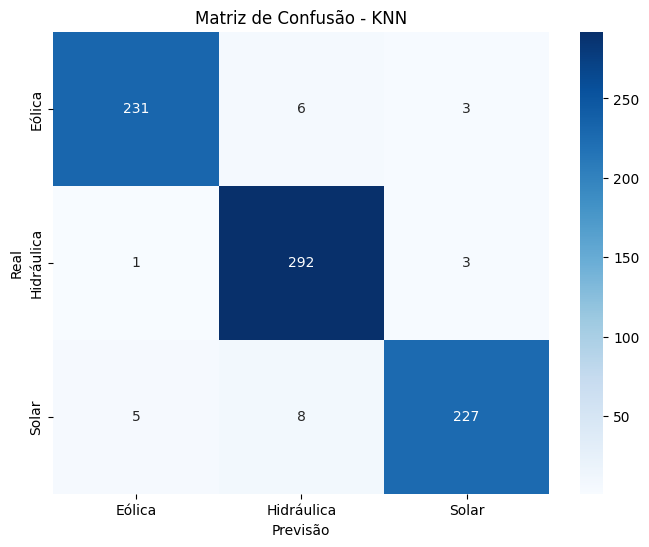

In [19]:
# 4.
classes_aneel = ['Eólica', 'Hidráulica', 'Solar']

# Matriz de confusão KNN
cm_knn = confusion_matrix(y_test_c, y_pred_knn, labels=classes_aneel)

plt.figure(figsize=(8, 6))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=classes_aneel, yticklabels=classes_aneel) # cria o heatmap colorido

#configuracoes
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão - KNN')

plt.show()

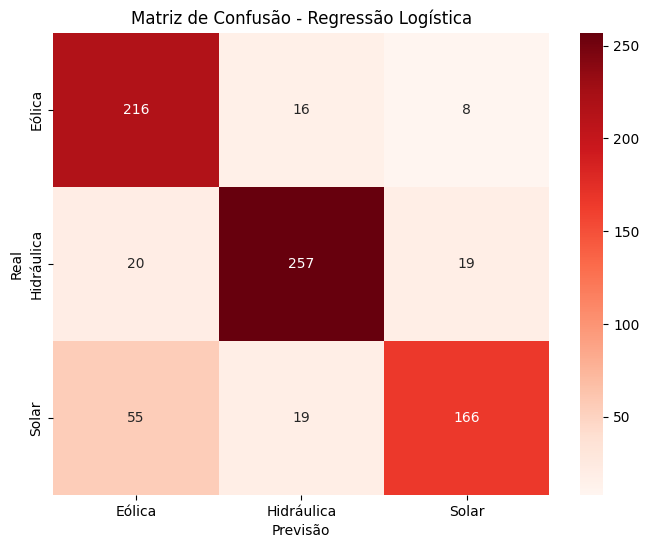

In [23]:
# Matriz de confusão regressão linear
cm_reg = confusion_matrix(y_test_c, y_pred_reg, labels=classes_aneel)

plt.figure(figsize=(8, 6))

sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Reds', xticklabels=classes_aneel, yticklabels=classes_aneel) # cria o heatmap colorido

#configuracoes
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')

plt.show()

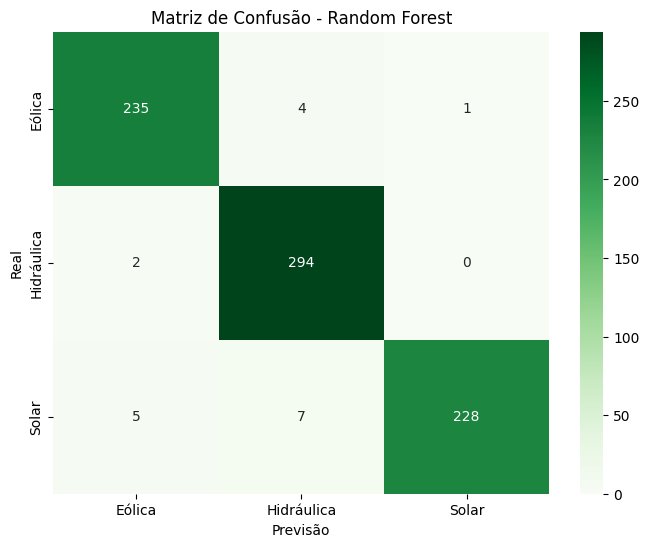

In [22]:
# Matriz de confusão Random forest
cm_rfor = confusion_matrix(y_test_c, y_pred_rfor, labels=classes_aneel)

plt.figure(figsize=(8, 6))

sns.heatmap(cm_rfor, annot=True, fmt='d', cmap='Greens', xticklabels=classes_aneel, yticklabels=classes_aneel) # cria o heatmap colorido

#configuracoes
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')

plt.show()

### Análise dos Resultados — ANEEL

* **Métricas:** Para Precisão, Recall e F1 foi utilizada a média **macro**, que calcula a métrica de cada classe separadamente e depois atribui o mesmo peso a todas as classes. Dessa forma, nenhuma classe é priorizada apenas por possuir maior quantidade de exemplos.

* **Comparação dos modelos:** Os três classificadores foram treinados utilizando a mesma divisão de treino e teste. O modelo com melhor desempenho geral deve ser escolhido considerando principalmente o F1, além da Acurácia, Precisão e Recall.

* **Classes mais confundidas:** As matrizes de confusão permitem identificar quais classes apresentam maior quantidade de erros. As classes mais confundidas foram **solar** e **eólica**, com uma confusão acentuada na matriz de Regressão Logística em classificar **solares como eólicos**.

* **Limitações:** No mundo real, classificar a fonte de um empreendimento utilizando apenas potência, latitude e longitude apresenta limitações importantes. Essas variáveis podem não ser suficientes para distinguir corretamente diferentes tecnologias de geração. Características como irradiação solar, regime de ventos, vazão dos rios, características do terreno, tecnologia utilizada e outras informações técnicas poderiam melhorar a classificação.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [24]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [25]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [26]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [27]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

----- Informações do dataset -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB

----- Primeiras linhas -----


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0



----- Valores ausentes -----
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

----- Resumo estatístico -----


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


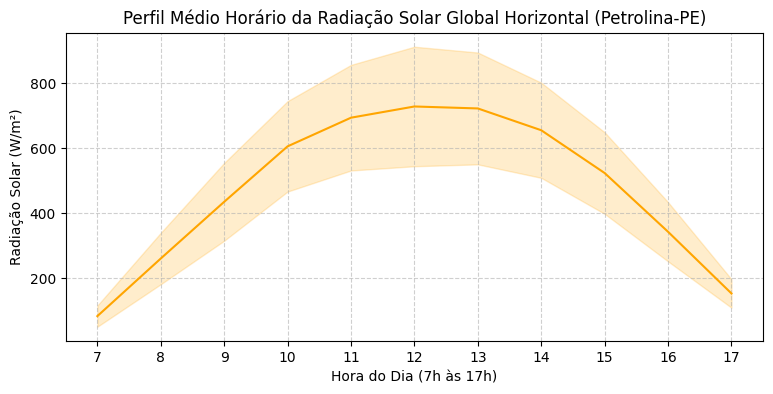

In [30]:
# 1. Análise inicial do dataset

df_regressao = pd.read_csv("meteo_regressao_orange.csv")

df_regressao["data_hora"] = pd.to_datetime(
    df_regressao["data_hora"]
)

df_regressao = (
    df_regressao
    .sort_values("data_hora")
    .reset_index(drop=True)
)

print(f"{'-'*5} Informações do dataset {'-'*5}")
df_regressao.info()

print(f"\n{'-'*5} Primeiras linhas {'-'*5}")
display(df_regressao.head())

print(f"\n{'-'*5} Valores ausentes {'-'*5}")
print(df_regressao.isnull().sum())

print(f"\n{'-'*5} Resumo estatístico {'-'*5}")
display(df_regressao.describe())

# Visualização
plt.figure(figsize=(9, 4))

sns.lineplot(
    data=df_regressao,
    x="hora",
    y="radiacao_w_m2",
    estimator="mean",
    errorbar="sd",
    color="orange"
)

plt.title(
    "Perfil Médio Horário da Radiação Solar Global Horizontal (Petrolina-PE)"
)
plt.xlabel("Hora do Dia (7h às 17h)")
plt.ylabel("Radiação Solar (W/m²)")
plt.xticks(range(7, 18))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [31]:
# 2. definir X, y e dividir
X_regressao = df_regressao[["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]]
y_regressao = df_regressao["radiacao_w_m2"]
split_point = int(len(df_regressao)* .8)

X_train_r = X_regressao.iloc[:split_point]
X_test_r = X_regressao.iloc[split_point:]
y_train_r = y_regressao.iloc[:split_point]
y_test_r = y_regressao.iloc[split_point:]

print(f"Total de amostras: {len(df_regressao)}")
print(f"Amostras de Treino (primeiros 80%): {len(X_train_r)}")
print(f"Amostras de Teste (últimos 20%): {len(X_test_r)}")

Total de amostras: 1001
Amostras de Treino (primeiros 80%): 800
Amostras de Teste (últimos 20%): 201


In [37]:
# 3. treinamento e avaliacao
# modelos: Regressão linear, Arvore de decisao e Random Forest

# Regressão linear

modelo_reg_regressao = LinearRegression()
modelo_reg_regressao.fit(X_train_r, y_train_r)
y_pred_reg_regressao = modelo_reg_regressao.predict(X_test_r)

mae_reg = mean_absolute_error(y_test_r, y_pred_reg_regressao)
mse_reg = mean_squared_error(y_test_r, y_pred_reg_regressao)
r2_reg = r2_score(y_test_r, y_pred_reg_regressao)

print(f"{'-'*5}Métricas Regressão Linear:{'-'*5}")
print(f"MAE:            {mae_reg:.4f}")
print(f"MSE:            {mse_reg:.4f}")
print(f"R²:             {r2_reg:.4f}")

# Arvore de decisao

modelo_arv_regressao = DecisionTreeRegressor(random_state=42)
modelo_arv_regressao.fit(X_train_r, y_train_r)
y_pred_arv_regressao = modelo_arv_regressao.predict(X_test_r)

mae_arv = mean_absolute_error(y_test_r, y_pred_arv_regressao)
mse_arv = mean_squared_error(y_test_r, y_pred_arv_regressao)
r2_arv = r2_score(y_test_r, y_pred_arv_regressao)

print(f"\n{'-'*5}Métricas Árvore de Decisão:{'-'*5}")
print(f"MAE:            {mae_arv:.4f}")
print(f"MSE:            {mse_arv:.4f}")
print(f"R²:             {r2_arv:.4f}")

# random forest

modelo_rfor_regressao = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rfor_regressao.fit(X_train_r, y_train_r)
y_pred_rfor_regressao = modelo_rfor_regressao.predict(X_test_r)

mae_rfor = mean_absolute_error(y_test_r, y_pred_rfor_regressao)
mse_rfor = mean_squared_error(y_test_r, y_pred_rfor_regressao)
r2_rfor = r2_score(y_test_r, y_pred_rfor_regressao)

print(f"\n{'-'*5}Métricas Random Forest:{'-'*5}")
print(f"MAE:            {mae_rfor:.4f}")
print(f"MSE:            {mse_rfor:.4f}")
print(f"R²:             {r2_rfor:.4f}")

-----Métricas Regressão Linear:-----
MAE:            145.2049
MSE:            30034.2011
R²:             0.3598

-----Métricas Árvore de Decisão:-----
MAE:            88.7910
MSE:            15291.1592
R²:             0.6741

-----Métricas Random Forest:-----
MAE:            66.8042
MSE:            7307.4179
R²:             0.8442


In [35]:
# Comparação dos três regressores

resultados_regressao = pd.DataFrame({
    "Modelo": ["Regressão Linear","Árvore de Decisão","Random Forest"],
    "MAE (W/m²)": [mae_reg,mae_arv,mae_rfor],
    "MSE ((W/m²)²)": [mse_reg,mse_arv,mse_rfor],
    "R²": [r2_reg,r2_arv,r2_rfor]
})

display(
    resultados_regressao.sort_values(
        "R²",
        ascending=False
    ).reset_index(drop=True)
)

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Random Forest,66.804179,7307.417901,0.844248
1,Árvore de Decisão,88.791045,15291.159204,0.674081
2,Regressão Linear,145.204885,30034.201092,0.359845


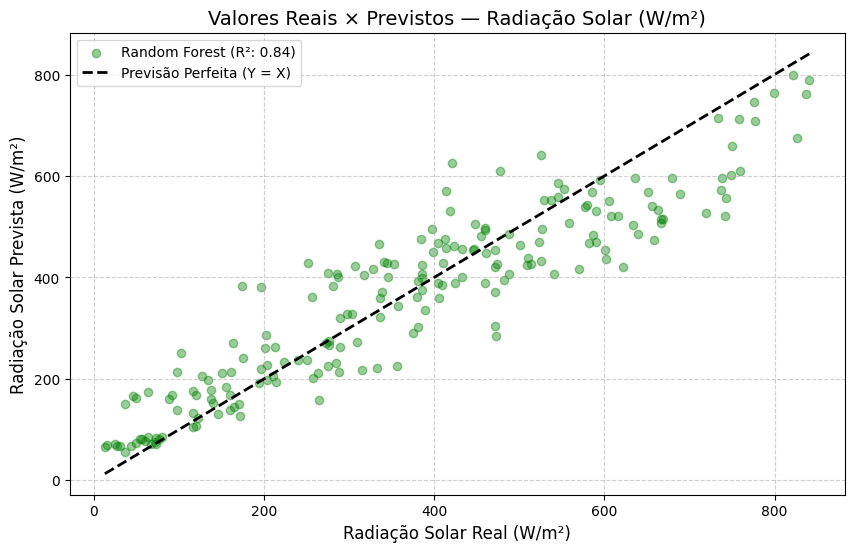

In [40]:
# 4. valores reais x previstos - random forest

# Tamanho da figura
plt.figure(figsize=(10, 6))

# Plota os pontos reais x previstos para cada um dos 3 modelos
plt.scatter(y_test_r, y_pred_rfor_regressao, alpha=0.4, label=f"Random Forest (R²: {r2_rfor:.2f})", color="green")

# Linha de referência perfeita (Y = X)
min_val = min(y_test_r.min(), y_pred_rfor_regressao.min())
max_val = max(y_test_r.max(), y_pred_rfor_regressao.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="Previsão Perfeita (Y = X)", linewidth=2)

# Configurações do gráfico
plt.title("Valores Reais × Previstos — Radiação Solar (W/m²)", fontsize=14)
plt.xlabel("Radiação Solar Real (W/m²)", fontsize=12)
plt.ylabel("Radiação Solar Prevista (W/m²)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Exibe o gráfico
plt.show()

### Análise dos Resultados de Regressão (Open-Meteo)
* Comparação dos Modelos: O Random Forest apresentou o melhor desempenho geral, obtendo o menor MAE e MSE e o maior valor de R².

* **Interpretação dos erros:** O MAE representa o erro absoluto médio das previsões em W/m², enquanto o MSE representa erros maiores. O R² indica quanto da variabilidade da radiação no conjunto de teste é explicada pelo modelo. Portanto, valores menores de MAE e MSE e valores maiores de R² indicam melhor desempenho.

* **Papel da hora do dia:** A variável hora é importante porque a radiação solar apresenta comportamento relacionado à posição do Sol. Dentro do intervalo analisado, a radiação tende a aumentar durante a manhã, atingir valores mais altos próximo ao meio-dia e diminuir durante a tarde. Por isso, conhecer a hora ajuda os modelos a representar esse padrão diário.

* **Radiação solar não é igual à geração fotovoltaica:** O alvo "radiacao_w_m2" representa a radiação solar global média da hora anterior, em W/m². Esse valor não corresponde diretamente à energia elétrica produzida por um sistema fotovoltaico, pois:

  1. **Orientação e inclinação:** a superfície do painel pode receber uma quantidade diferente de radiação dependendo de sua orientação e inclinação.
  
  2. **Características dos módulos:** a eficiência de conversão dos painéis determina quanto da radiação incidente pode ser convertida em eletricidade.
  
  3. **Temperatura:** a temperatura do módulo influencia sua eficiência elétrica.
  
  4. **Perdas do sistema:** sujeira, sombreamento, cabeamento, inversor e outras perdas também afetam a geração.
  
  5. **Potência instalada:** a energia produzida depende também da quantidade e da potência dos módulos instalados.

Assim, o modelo deste trabalho estima a **radiação solar**, e não a energia elétrica gerada por uma usina fotovoltaica.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)